In [1]:
pip list

Package                   Version
------------------------- -----------
absl-py                   2.4.0
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
astunparse                1.6.3
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
blinker                   1.9.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.6
click                     8.3.1
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
et_xmlfile                2.0.0
executing                 2.2.1
fastjsonschema            2.21.2
Flask                     3.1.3
flatbuffers        

In [2]:
import tensorflow as tf
import os
print("done")

done


In [3]:
gpus = tf.config.experimental.list_physical_devices('CPU')

In [4]:
gpus

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [5]:
import cv2
import PIL
print("DONE")

DONE


In [6]:
data_dir = 'data11/train'

In [7]:
os.listdir(data_dir)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise', 'weapon']

In [8]:
image_exts = ['jpeg','jpg','bmp','png']

In [9]:
image_exts

['jpeg', 'jpg', 'bmp', 'png']

In [10]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir,image_class)): #ismein seprate folader happy and sad koliya jayga like data happy,data sad
        image_path =os.path.join(data_dir,image_class,image) #ismein dono combine honge
        print("photo we are rendering is:",image_path)
        try:
            img=cv2.imread(image_path) #image kholta hai
            #tip=PIL.what(image_path)
            if img is None:
                print('image not in ext list{}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('issue with image()'.format(image_path), e)
            #os.remove(image_path)

photo we are rendering is: data11/train\angry\00b4f95d5919ee8f3592ec93fb49ddf7.jpg
photo we are rendering is: data11/train\angry\0765.png
photo we are rendering is: data11/train\angry\1000_F_115345038_aiR85n4vBu8ul6zlfsFY6QjvHJji6tuW.jpg
photo we are rendering is: data11/train\angry\116999ecb25ac04c42cdac0a91c578439f-29-angry-face-rsocial-w12.jpg
photo we are rendering is: data11/train\angry\13-little-boy-angry-face-cartoon-clipart.jpg
photo we are rendering is: data11/train\angry\1f621.png
photo we are rendering is: data11/train\angry\206738876-angry-woman-face-vector-illustration-of-a-girl-wit.jpg
photo we are rendering is: data11/train\angry\2595218-child-portrait-or-angry-face-on-isolated-red-backgro.jpg
photo we are rendering is: data11/train\angry\3046860-angry-emoji-vinyl-and-sticker-print-of-face-cartoon-.jpg
photo we are rendering is: data11/train\angry\32-512.png
photo we are rendering is: data11/train\angry\360_anger.jpg
photo we are rendering is: data11/train\angry\360_F_15

In [11]:
import numpy as np
from matplotlib import pyplot as plt

In [12]:
tf.keras.utils.image_dataset_from_directory('data11/train',batch_size=8,image_size=(128,128))

Found 37407 files belonging to 8 classes.


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [13]:
import os
print("data exists:", os.path.exists("data"))
if os.path.exists("data"):
    print("Inside data:", os.listdir("data"))


data exists: True
Inside data: ['test', 'train', '_quarantine_bad_images', '_quarantine_bad_images_tiny']


In [14]:
train_dataset = tf.keras.utils.image_dataset_from_directory('data11/train')

Found 37407 files belonging to 8 classes.


In [15]:
data_iterator = train_dataset.as_numpy_iterator()

In [16]:
data_iterator

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x000001C379C8EA50>)

In [17]:
#get another batch from iterator
batch =data_iterator.next()

In [18]:
#represented as numpy rise
batch[0].shape

(32, 256, 256, 3)

In [19]:
batch[1]

array([0, 3, 3, 2, 5, 3, 0, 3, 2, 2, 0, 5, 3, 6, 4, 6, 0, 3, 5, 4, 5, 6,
       3, 5, 2, 5, 5, 3, 4, 6, 3, 0], dtype=int32)

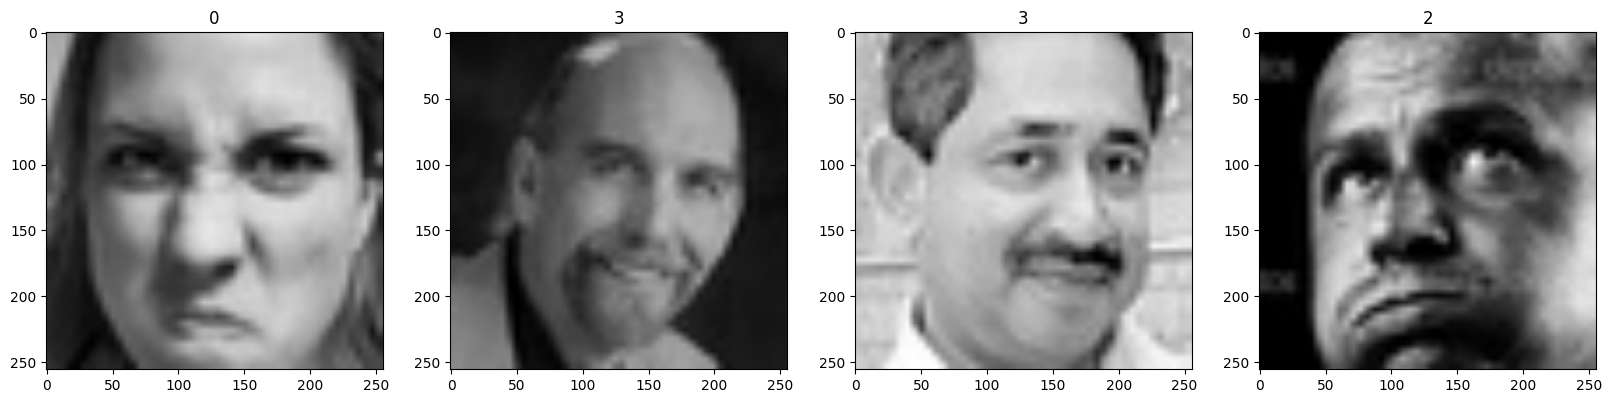

In [20]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
     ax[idx].imshow(img.astype(int))
     ax[idx].title.set_text(batch[1][idx])

In [21]:
name= batch[0].max()
print(name)

255.0


In [22]:
scaled = batch[0]/name

In [23]:
scaled.min()

np.float32(0.0)

In [24]:
scaled_dataset = train_dataset.map(lambda x, y: (x /name, y))

In [25]:
scaled_dataset.as_numpy_iterator().next()[0].max()

np.float32(1.0)

In [26]:
scaled_iterator=scaled_dataset.as_numpy_iterator()

In [27]:
scaled_iterator.next()

(array([[[[0.44313726, 0.44313726, 0.44313726],
          [0.44313726, 0.44313726, 0.44313726],
          [0.44313726, 0.44313726, 0.44313726],
          ...,
          [0.56078434, 0.56078434, 0.56078434],
          [0.56078434, 0.56078434, 0.56078434],
          [0.56078434, 0.56078434, 0.56078434]],
 
         [[0.44313726, 0.44313726, 0.44313726],
          [0.44313726, 0.44313726, 0.44313726],
          [0.44313726, 0.44313726, 0.44313726],
          ...,
          [0.56078434, 0.56078434, 0.56078434],
          [0.56078434, 0.56078434, 0.56078434],
          [0.56078434, 0.56078434, 0.56078434]],
 
         [[0.44313726, 0.44313726, 0.44313726],
          [0.44313726, 0.44313726, 0.44313726],
          [0.44313726, 0.44313726, 0.44313726],
          ...,
          [0.56078434, 0.56078434, 0.56078434],
          [0.56078434, 0.56078434, 0.56078434],
          [0.56078434, 0.56078434, 0.56078434]],
 
         ...,
 
         [[0.5647059 , 0.5647059 , 0.5647059 ],
          [0.56470

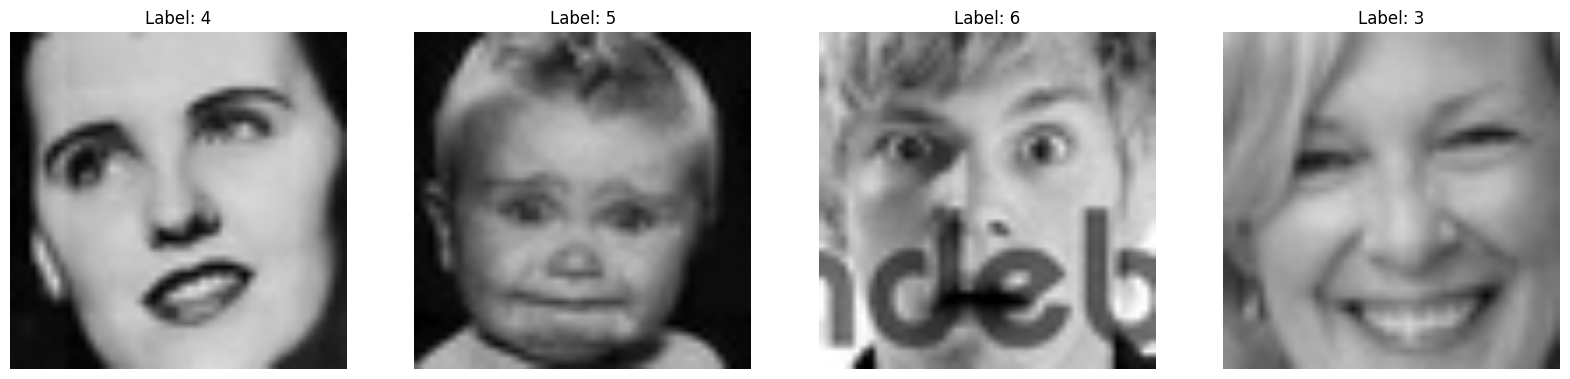

In [28]:
# Make sure you have a scaled dataset
# (We created this in a previous step)
scaled_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))

# Get a batch from the SCALED dataset
scaled_iterator = scaled_dataset.as_numpy_iterator()
batch = scaled_iterator.next()

# Now, your plotting code will work WITHOUT warnings, because the values are already between 0 and 1
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img) # 'img' is now floats between 0.0 and 1.0
    ax[idx].set_title(f'Label: {batch[1][idx]}')
    ax[idx].axis('off')    
plt.show()

In [29]:
import tensorflow as tf
from matplotlib import pyplot as plt

# This loads the data from your folder.
# The pixel values will be floats from 0-255.
train_dataset = tf.keras.utils.image_dataset_from_directory('data11/train',image_size=(48, 48),batch_size=32,label_mode='int') 
# Use 'int' for simpler labels like 0, 1, 2...

Found 37407 files belonging to 8 classes.


In [30]:
scaled = batch[0] / name
max_value_as_float = scaled.max()
max_value_as_int = int(max_value_as_float)

print("The max value (correctly as a float):", max_value_as_float)
print("The max value (converted to an integer):", max_value_as_int)

The max value (correctly as a float): 0.003921569
The max value (converted to an integer): 0


In [31]:
name= batch[0].max()
print(name)

1.0


In [32]:
# This creates a new, scaled dataset where pixel values are from 0.0-1.0
scaled_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))

print("✅ Step 2 complete: Data scaling pipeline is ready.")

✅ Step 2 complete: Data scaling pipeline is ready.


In [33]:
train_dataset=train_dataset.map(lambda x,y: (x/name,y))

In [34]:
batch =scaled_iterator.next()

In [35]:
scaled_iterator =train_dataset.as_numpy_iterator()

In [36]:
train_dataset.as_numpy_iterator().next()[0].max()

np.float32(255.0)

In [37]:
len(train_dataset)

1169

In [38]:
import tensorflow as tf

# --- The Correct Way to Load AND Split Your Data ---

DATA_DIR = 'data11/train'      # The path to your folder with image subdirectories
IMAGE_SIZE = (48, 48)        # The image size you are using
BATCH_SIZE = 32              # A standard batch size
VALIDATION_SPLIT = 0.2       # We will use 20% of the data for validation

# --- Create the TRAINING dataset (80% of the data) ---
# We tell the function to split the data and give us the 'training' subset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=123,                # The seed ensures the split is the same every time
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# --- Create the VALIDATION dataset (20% of the data) ---
# We tell the function to split the data again and give us the 'validation' subset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=123,                # Using the same seed is CRITICAL to prevent data overlap
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 37407 files belonging to 8 classes.
Using 29926 files for training.
Found 37407 files belonging to 8 classes.
Using 7481 files for validation.


In [39]:
print(f"Number of batches in the training set: {len(train_dataset)}")
print(f"Number of batches in the validation set: {len(validation_dataset)}")

Number of batches in the training set: 936
Number of batches in the validation set: 234


In [40]:
import os

# The path we are investigating
DATA_DIR = 'data11/train'
print(f"--- DIAGNOSING FOLDER STRUCTURE ---")
print(f"Looking inside: '{os.path.abspath(DATA_DIR)}'\n")

if not os.path.exists(DATA_DIR):
    print(f"!!! CRITICAL ERROR: The directory '{DATA_DIR}' does not exist! Please check the path. !!!")
else:
    # List the items directly inside DATA_DIR
    top_level_items = os.listdir(DATA_DIR)
    print(f"Found {len(top_level_items)} item(s) directly inside '{DATA_DIR}':")
    for item in top_level_items:
        print(f"  - {item}")

    # Check the first item to see what's inside it
    if top_level_items:
        first_item_path = os.path.join(DATA_DIR, top_level_items[0])
        if os.path.isdir(first_item_path):
            print(f"\nLooking inside the first item '{top_level_items[0]}':")
            second_level_items = os.listdir(first_item_path)
            for sub_item in second_level_items:
                print(f"  - {sub_item}")

--- DIAGNOSING FOLDER STRUCTURE ---
Looking inside: 'C:\Users\vidhu\Desktop\all.files\TFProj\data11\train'

Found 8 item(s) directly inside 'data11/train':
  - angry
  - disgust
  - fear
  - happy
  - neutral
  - sad
  - surprise
  - weapon

Looking inside the first item 'angry':
  - 00b4f95d5919ee8f3592ec93fb49ddf7.jpg
  - 0765.png
  - 1000_F_115345038_aiR85n4vBu8ul6zlfsFY6QjvHJji6tuW.jpg
  - 116999ecb25ac04c42cdac0a91c578439f-29-angry-face-rsocial-w12.jpg
  - 13-little-boy-angry-face-cartoon-clipart.jpg
  - 1f621.png
  - 206738876-angry-woman-face-vector-illustration-of-a-girl-wit.jpg
  - 2595218-child-portrait-or-angry-face-on-isolated-red-backgro.jpg
  - 3046860-angry-emoji-vinyl-and-sticker-print-of-face-cartoon-.jpg
  - 32-512.png
  - 360_anger.jpg
  - 360_F_1556900799_SR0d7LnBRUP72RhISeYjnMznIpDKRdXh.jpg
  - 360_F_73243993_WfQ6CwwVbsSf36W0oLaCseTecG6dQMFm.jpg
  - 39843011-angry-face-man.jpg
  - 3HKnHJ2HPXpcrdOaKwvbr1fcGfYjPAIjBjhP5Kea-5OG5x9hMpGdv8NcTRch.jpeg
  - 411-4117535_ang

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten

# Create a new sequential model
model = Sequential()

# ---- The Fix ----
# Add the Input layer as the very first layer
model.add(Input(shape=(256, 256, 3)))

# ---- The Rest of Your Model (Now without 'input_shape' in the first Conv2D) ----
# I also removed the extra '1' for the stride, as it is the default value
model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# This will now print the summary without any warnings
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [43]:
logdir='logs'

In [44]:
tensorboard_callback =tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [45]:
import tensorflow as tf

m = tf.keras.models.load_model("emotion_best.keras", compile=False)
print("model output:", m.output_shape)


model output: (None, 8)


In [46]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- 1. Settings ---
IMAGE_SIZE = (48, 48)
BATCH_SIZE = 16      # smaller batch → better accuracy
EPOCHS = 40          # more epochs → better learning
SEED = 123
DATA_ROOT = 'data11/train'
CKPT = 'emotion_best.keras'

# --- 2. Datasets ---
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    color_mode='rgb',
    shuffle=True
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    color_mode='rgb',
    shuffle=False
)

CLASS_NAMES = train_dataset.class_names
NUM_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES, "-> NUM_CLASSES =", NUM_CLASSES)

# --- 3. Scaling + Prefetch ---
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))
    .cache()
    .prefetch(AUTOTUNE)
)

val_dataset = (
    val_dataset
    .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))
    .cache()
    .prefetch(AUTOTUNE)
)

# --- 4. Model ---
model = Sequential([
    Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D(),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(),

    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5. Callbacks ---
cbs = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ModelCheckpoint(CKPT, monitor='val_loss', save_best_only=True)
]

# --- 6. Train ---
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=cbs
)

print("\nTraining complete! Best weights saved to:", CKPT)


Found 37407 files belonging to 8 classes.
Using 29926 files for training.
Found 37407 files belonging to 8 classes.
Using 7481 files for validation.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise', 'weapon'] -> NUM_CLASSES = 8
Epoch 1/40
1871/1871 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - accuracy: 0.3485 - loss: 1.6741 - val_accuracy: 0.4326 - val_loss: 1.6368
Epoch 2/40
1871/1871 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.4409 - loss: 1.4607 - val_accuracy: 0.5328 - val_loss: 1.3310
Epoch 3/40
1871/1871 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.4782 - loss: 1.3702 - val_accuracy: 0.5402 - val_loss: 1.2702
Epoch 4/40
1871/1871 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.5050 - loss: 1.3049 - val_accuracy: 0.6038 - val_loss: 1.2177
Epoch 5/40
1871/1871 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - accuracy: 0.5246 - loss: 1.2552 - val_accuracy: 0.6134 - val_loss: 1.1552
Epoch 6/40
1871/1871 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - accuracy: 0.5436 - loss: 1.

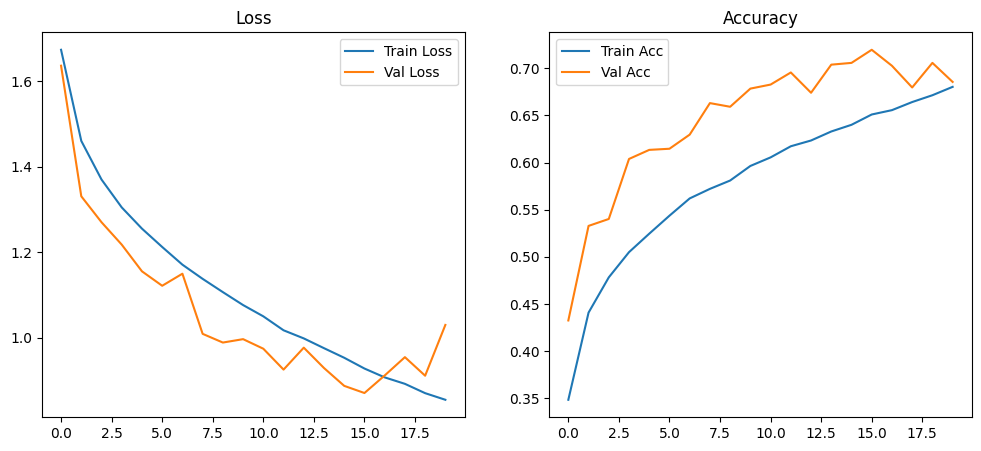

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.show()


Found 37407 files belonging to 8 classes.
Using 7481 files for validation.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise', 'weapon']
468/468 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step
y_true shape: (7481,)
y_pred shape: (7481,)
Confusion Matrix (raw):
 [[   0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0]
 [ 247    8  153  151  356 1976   22   24]
 [ 146   18  301  279  134  197 3032    4]
 [  12    2    4   13    2   24    1  375]]

Classification report:
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00         0
     disgust       0.00      0.00      0.00         0
        fear       0.00      0.00      0.00         0
       happy       0.00      0.00      0.00         0
     neutral       0.00      0.00      0.00         0
         sad       0.90      0.67

C:\Users\vidhu\Desktop\all.files\research\tfvenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vidhu\Desktop\all.files\research\tfvenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vidhu\Desktop\all.files\research\tfvenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

<Figure size 800x600 with 0 Axes>

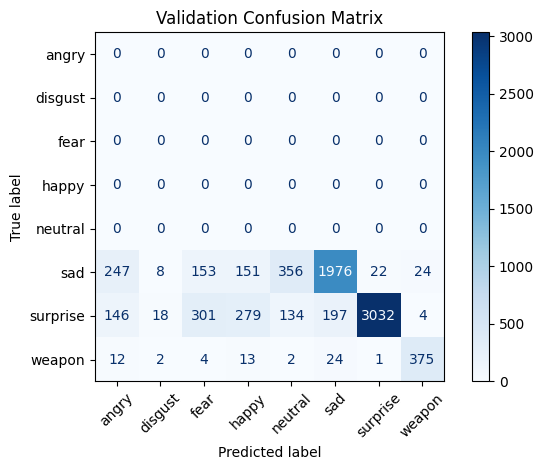

In [48]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# --- SAME SETTINGS AS TRAINING ---
IMAGE_SIZE = (48, 48)
BATCH_SIZE = 16
SEED = 123
DATA_ROOT = 'data11/train'        # same as training
CKPT = 'emotion_best.keras'       # trained model path

# --- 1. VALIDATION DATASET (same split) ---
val_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    color_mode='rgb',
    shuffle=False       # IMPORTANT: don't shuffle for confusion matrix
)

CLASS_NAMES = val_raw.class_names
print("Classes:", CLASS_NAMES)

AUTOTUNE = tf.data.AUTOTUNE

def scale_images(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, y

val_ds = (
    val_raw
    .map(scale_images)
    .prefetch(AUTOTUNE)
)

# --- 2. LOAD TRAINED MODEL ---
model = tf.keras.models.load_model(CKPT)

# --- 3. TRUE LABELS & PREDICTIONS ---
y_true = np.concatenate([y.numpy() for x, y in val_ds])

y_probs = model.predict(val_ds)
y_pred = np.argmax(y_probs, axis=1)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

# --- 4. CONFUSION MATRIX ---
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix (raw):\n", cm)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# --- 5. PLOT MATRIX ---
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()


In [49]:
# Cell 1: Install dependencies (run once)
!pip install fastapi uvicorn python-multipart pillow tensorflow

# Cell 2: Your existing code + server
import uvicorn
import numpy as np
from fastapi import FastAPI, UploadFile, File
from fastapi.responses import JSONResponse
from fastapi.middleware.cors import CORSMiddleware
from PIL import Image
import tensorflow as tf
import json
import io
import nest_asyncio

# Allow nested event loops (needed for Jupyter)
nest_asyncio.apply()

app = FastAPI()

# IMPORTANT: Add CORS so frontend can connect
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],  # In production, specify your frontend URL
    allow_methods=["*"],
    allow_headers=["*"],
)

# Load model + labels
MODEL_PATH = "emotion_best.keras"
LABELS_PATH = "emotion_labels.json"

model = tf.keras.models.load_model(MODEL_PATH, compile=False)

with open(LABELS_PATH, "r") as f:
    labels = json.load(f)["class_names"]

def read_image(file):
    img = Image.open(io.BytesIO(file)).convert("RGB")
    img = img.resize((48, 48))
    arr = np.asarray(img).astype("float32") / 255.0
    arr = np.expand_dims(arr, axis=0)
    return arr

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    try:
        contents = await file.read()
        x = read_image(contents)
        probs = model.predict(x)[0]

        top_idx = int(np.argmax(probs))
        top_label = labels[top_idx]
        top_prob = float(probs[top_idx])

        return {
            "status": "success",
            "prediction": top_label,
            "confidence": round(top_prob, 4),
            "all_probs": {labels[i]: float(probs[i]) for i in range(len(labels))}
        }
    except Exception as e:
        return JSONResponse(status_code=400, content={"status": "error", "reason": str(e)})

# Run server (this will block the cell)
uvicorn.run(app, host="0.0.0.0", port=8000)

  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.1 MB 3.7 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 3.4 MB/s  0:00:00
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)

   ---- ----------------------------------- 1/9 [python-multipart]
   ---- ----------------------------------- 1/9 [python-multipart]
   -------- ------------------------------- 2/9 [pydantic-core]
   -------- ------------------------------- 2/9 [pydantic-core]
   ----------------- ---------------------- 4/9 [annotated-doc]
   ---------------------- ----------------- 5/9 [uvicorn]
   ---------------------- ----------------- 5/9 [uvico

RuntimeError: asyncio.run() cannot be called from a running event loop